# 06 - Define the Commute Risk Metric

Now that we have generated school routes across South Yorkshire and merged them with the STATS19 collision dataset, we aim to identify the risk level of each route. However, defining what makes a route “dangerous” is not straightforward. For example, simply using the number of collisions or casualties would unfairly penalize longer routes, which naturally cover more area and have greater exposure.

Therefore, in this notebook, we explore multiple candidate approaches to fairly assess and compare the relative danger levels of routes, with a particular focus on avoiding arbitrary scoring systems.

In [19]:
# autoreload setup
%load_ext autoreload
%autoreload 2

# imports
import importlib
from util import commute_risk_metrics as crm
importlib.reload(crm)
import pandas as pd
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
df = pd.read_csv('../data/stats19_routes_combined.csv', low_memory=False)

## Step 1: Build Route-Level Base Metrics

- Total collision count  
- Total casualty count  
- Total severe injuries

These are useful for intuition but **biased toward longer or more-used routes**. Not used in final ranking, shown for reference only.





In [42]:
crm_table = crm.build_commute_risk_metrics(df)
# display(crm_table)

## 2. Per-Kilometre Normalized Metrics

We calculate per-km values for the base metrics defined above. This adjustment accounts for variation in route lengths.

In [43]:
metric_cols = [
  "collision_count", 
  "casualty_count", 
  "avg_casualty_severity", 
  "serious_fatal_casualty_count"
]
crm_table = crm.add_normalised_metrics(crm_table, metric_cols)
# display(crm_table)

### 3. Percentile Rankings
We add columns for percentile ranks for each of the previously defined metrics.

In [44]:
normalised_cols = [f"{col}_per_km" for col in metric_cols]
crm_table = crm.add_percentile_metrics(crm_table, normalised_cols)
# display(crm_table)

### 4. Metrics based on Poisson Regression
We use Poisson regression to model expected values based on route length, then compute:
- expected_per_km
- risk_ratio
- excess_per_km

In [45]:
crm_table = crm.add_poisson_risk_metrics(crm_table, metric_cols)

poisson_excess_cols = [f"poisson_excess_per_km_{col}" for col in metric_cols]
crm_table = crm.add_percentile_metrics(crm_table, poisson_excess_cols)
# display(crm_table)


5. Add Composite Scores for Percentiles
Here, we create a percentile composite rank each for the normalised percentile ranks (normal counts) and Poisson percentile ranks (excess counts), and then create a meta composite percentile rank for both of these.

In [46]:
# Composite from count-based percentiles
count_percentiles = [f"{col}_per_km_percentile" for col in metric_cols]
crm_table = crm.add_composite_percentile(crm_table, count_percentiles, prefix="count")

# Composite from Poisson-based excess per km percentiles
poisson_percentiles = [f"poisson_excess_per_km_{col}_percentile" for col in metric_cols]
crm_table = crm.add_composite_percentile(crm_table, poisson_percentiles, prefix="poisson")

# Meta-composite combining both
crm_table = crm.add_composite_percentile(
    crm_table,
    ["count_percentile", "poisson_percentile"],
    prefix="meta"
)
display(crm_table)

,route_id,school_name,borough,length_km,collision_count,casualty_count,avg_casualty_severity,serious_fatal_casualty_count,collision_count_per_km,casualty_count_per_km,...,poisson_expected_per_km_serious_fatal_casualty_count,poisson_risk_ratio_serious_fatal_casualty_count,poisson_excess_per_km_serious_fatal_casualty_count,poisson_excess_per_km_collision_count_percentile,poisson_excess_per_km_casualty_count_percentile,poisson_excess_per_km_avg_casualty_severity_percentile,poisson_excess_per_km_serious_fatal_casualty_count_percentile,count_percentile,poisson_percentile,meta_percentile
0,de_warenne_academy_15,De Warenne Academy,Doncaster,6.622,69,98,2.612245,28,10.419813,14.799154,...,1.065447,3.968598,3.162883,0.810974,0.801703,0.050710,0.979376,0.740965,0.741249,0.741154
1,don_valley_academy_7,Don Valley Academy,Doncaster,6.626,22,32,2.718750,8,3.320254,4.829460,...,1.065447,1.133201,0.141918,0.366320,0.342857,0.061306,0.651088,0.289120,0.291107,0.290066
2,ridgewood_school_6,Ridgewood School,Doncaster,5.890,10,15,2.600000,5,1.697793,2.546689,...,1.065447,0.796752,-0.216550,0.196594,0.189593,0.086850,0.532640,0.132072,0.133586,0.131883
3,sir_thomas_wharton_academy_16,Sir Thomas Wharton Academy,Doncaster,5.807,84,117,2.837607,17,14.465300,20.148097,...,1.065447,2.747675,1.862055,0.911637,0.904068,0.166887,0.927342,0.831883,0.832450,0.831883
4,stone_hill_school_6,Stone Hill School,Doncaster,5.683,10,14,2.714286,3,1.759634,2.463488,...,1.065447,0.495464,-0.537557,0.202649,0.183160,0.142100,0.391864,0.109366,0.107190,0.108042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5280,the_robert_ogden_school_21,The Robert Ogden School,Barnsley,6.141,1,1,3.000000,0,0.162840,0.162840,...,1.065447,0.000000,-1.065447,0.007569,0.006623,0.166131,0.173888,0.013056,0.017408,0.014948
5281,the_robert_ogden_school_22,The Robert Ogden School,Barnsley,6.676,1,1,3.000000,0,0.149790,0.149790,...,1.065447,0.000000,-1.065447,0.006055,0.005487,0.097256,0.177105,0.006055,0.010974,0.008325
5282,sacred_heart_rc_primary_school_6,Sacred Heart Rc Primary School,Barnsley,2.288,1,2,3.000000,0,0.437063,0.874126,...,1.065447,0.000000,-1.065447,0.049763,0.067550,0.837086,0.057143,0.146547,0.136045,0.141533
5283,meersbrook_bank_primary_1,Meersbrook Bank Primary,Sheffield,0.742,1,4,3.000000,0,1.347709,5.390836,...,1.065447,0.000000,-1.065447,0.157900,0.378997,0.987039,0.005582,0.355913,0.329801,0.342100


We see that the baseline is ~6 collisions per km. It is what is expected collision density per km if all routes had the same risk level. Now, we can visualise how the actual collisions look compared to baseline for each route.

##### Plotting Residual Risk

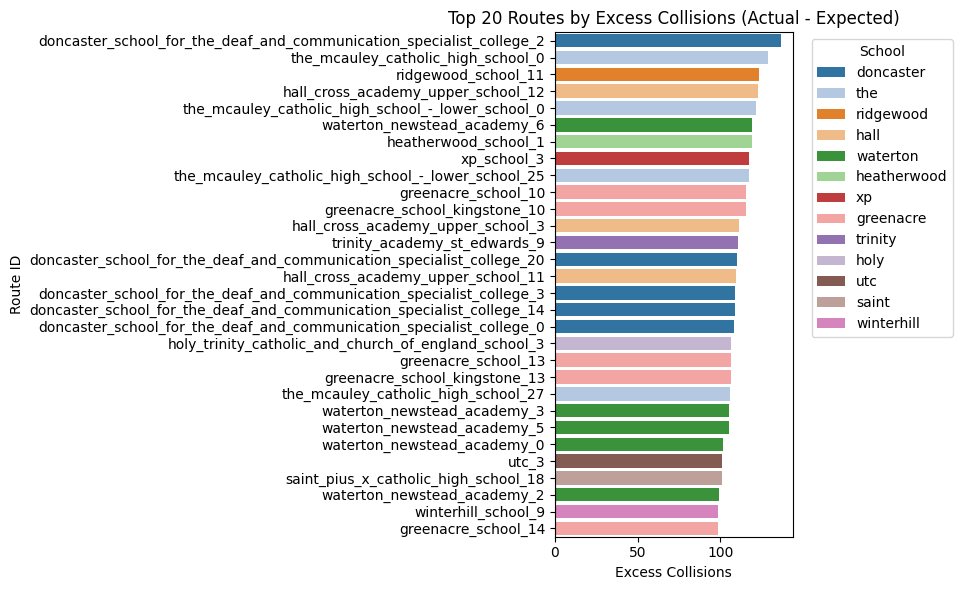

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract school name from route_id prefix
df_model["school_name"] = df_model["route_id"].str.extract(r"(^[^_]+)")

# Calculate residuals
df_model["residual"] = df_model["collisions"] - df_model["expected"]

# Select top 20 by excess collisions
top_residuals = df_model.sort_values("residual", ascending=False).head(30)

# Color by school
school_palette = dict(zip(
    top_residuals["school_name"].unique(),
    sns.color_palette("tab20", n_colors=top_residuals["school_name"].nunique())
))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_residuals,
    x="residual",
    y="route_id",
    hue="school_name",
    dodge=False,
    palette=school_palette
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Top 20 Routes by Excess Collisions (Actual - Expected)")
plt.xlabel("Excess Collisions")
plt.ylabel("Route ID")
plt.legend(title="School", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



this is interesting, also checked out google maps for doncaster school for the deaf, and its right next to a big highway roundabout.

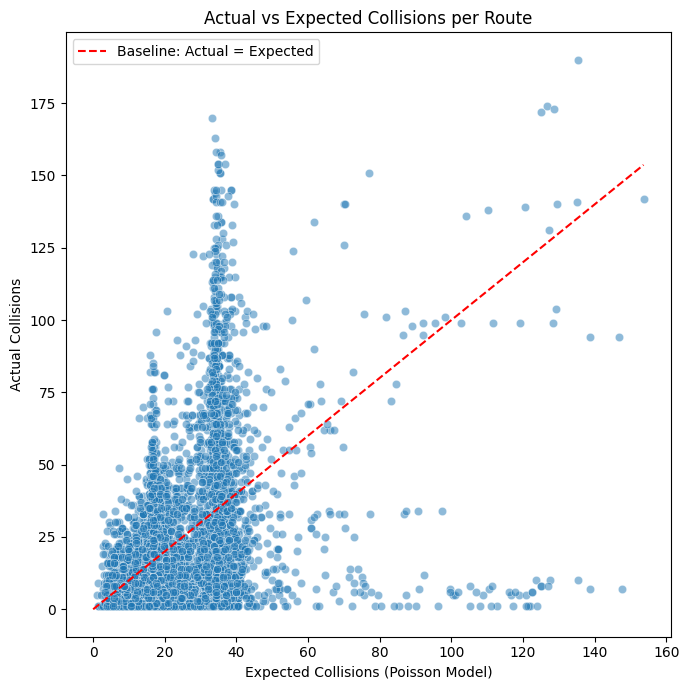

In [25]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_model, x="expected", y="collisions", alpha=0.5)
plt.plot([0, df_model["expected"].max()], [0, df_model["expected"].max()], color="red", linestyle="--", label="Baseline: Actual = Expected")
plt.xlabel("Expected Collisions (Poisson Model)")
plt.ylabel("Actual Collisions")
plt.title("Actual vs Expected Collisions per Route")
# plt.xscale("log")
# plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()


<Axes: xlabel='expected', ylabel='collisions'>

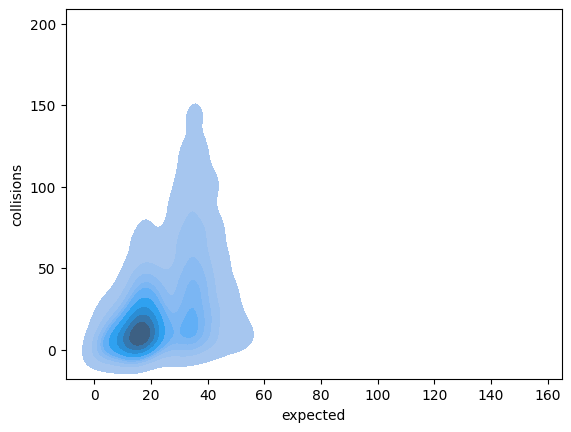

In [ ]:
sns.kdeplot(data=df_model, x="expected", y="collisions", fill=True, thresh=0.05)

### 1.5. Statistical Risk Modelling - Negative Binomial Regression
In this section, we aim to model the relative risk of school routes across South Yorkshire using Negative Binomial Regression. This approach is suitable for overdispersed count data, where the variance exceeds the mean—common in collision and casualty datasets.

Traditional Poisson regression assumes that the mean and variance of the response variable are equal. However, our dataset exhibits overdispersion due to:
* Varying route lengths (exposure),
* Sparse filtering (e.g., pedestrians only, specific years),
* A high frequency of zero or low collision counts.
Negative Binomial regression introduces a dispersion parameter to better accommodate this variability, offering more reliable coefficient estimates and model fit.

### 1.6. Implementing Machine Learning for Classfication of Routes into Risk level groups